In [5]:
!pip install lightgbm


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


SECTION A

In [42]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random

In [8]:
file_path = 'C:/Users/olulo/Downloads/CYBER REPORT/archive/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv'
df = pd.read_csv(file_path, low_memory=False)
#df = pd.read_csv('C:/Users/olulo/Downloads/CYBER REPORT/archive/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv')

In [9]:
print('Dataset shape:', df.shape)
print(df[['Attack_label', 'Attack_type']].value_counts().head())
print(df.info())

Dataset shape: (157800, 63)
Attack_label  Attack_type
0             Normal         24301
1             DDoS_UDP       14498
              DDoS_ICMP      14090
              Ransomware     10925
              DDoS_HTTP      10561
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  object 
 1   ip.src_host                157800 non-null  object 
 2   ip.dst_host                157800 non-null  object 
 3   arp.dst.proto_ipv4         157800 non-null  object 
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  object 
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   ic

In [10]:
#Preprocessing
numeric_df = df.select_dtypes(include=['number']).copy()
X = numeric_df.drop(['Attack_label'], axis=1)
y = numeric_df['Attack_label']

In [11]:
#Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#Build and Train LightGBM Model
#lgb_train = lgb.Dataset(X_train_scaled, y_train)
#lgb_eval = lgb.Dataset(X_test_scaled, y_test, reference=lgb_train)

#params = {
#    'objective': 'binary',
#    'metric': 'binary_logloss',
#    'boosting_type': 'gbdt',
#    'num_leaves': 31,
#   'learning_rate': 0.05,
#   'verbose': -1,
#    'random_state': 42
#}

#model = lgb.train(params, lgb_train, valid_sets=[lgb_train, lgb_eval], num_boost_round=100,
 #                 early_stopping_rounds=10, verbose_eval=False)

In [13]:
# Create datasets
lgb_train = lgb.Dataset(X_train_scaled, y_train)
lgb_eval = lgb.Dataset(X_test_scaled, y_test, reference=lgb_train)

# Define parameters
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 15,
    'learning_rate': 0.01,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_child_samples': 20,
    'seed': 42,
    'verbose': -1
}

# Train with early stopping via callbacks
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_eval],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=10,
            min_delta=0.001  # Stop if improvement < 0.001
        ),
        lgb.log_evaluation(10) 
        ]
)

Training until validation scores don't improve for 10 rounds
[10]	valid_0's binary_logloss: 0.352603
[20]	valid_0's binary_logloss: 0.299521
[30]	valid_0's binary_logloss: 0.25917
[40]	valid_0's binary_logloss: 0.226931
[50]	valid_0's binary_logloss: 0.200414
[60]	valid_0's binary_logloss: 0.178151
[70]	valid_0's binary_logloss: 0.159192
[80]	valid_0's binary_logloss: 0.142874
[90]	valid_0's binary_logloss: 0.128715
[100]	valid_0's binary_logloss: 0.116342
[110]	valid_0's binary_logloss: 0.105463
[120]	valid_0's binary_logloss: 0.0958213
[130]	valid_0's binary_logloss: 0.0872474
[140]	valid_0's binary_logloss: 0.0796542
[150]	valid_0's binary_logloss: 0.0729091
[160]	valid_0's binary_logloss: 0.0669116
[170]	valid_0's binary_logloss: 0.0615659
[180]	valid_0's binary_logloss: 0.0568013
[190]	valid_0's binary_logloss: 0.0525474
[200]	valid_0's binary_logloss: 0.0486873
[210]	valid_0's binary_logloss: 0.0452422
[220]	valid_0's binary_logloss: 0.0421661
[230]	valid_0's binary_logloss: 0.03

In [14]:
#Evaluate Model
y_pred = model.predict(X_test_scaled)
y_pred_labels = (y_pred > 0.5).astype(int)

print("Part A - LightGBM Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_labels):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_labels):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_labels):.4f}")

Part A - LightGBM Model Performance:
Accuracy: 0.9952
Precision: 0.9978
Recall: 0.9966
F1 Score: 0.9972


SECTION B

In [16]:
#Sophisticated Poisoning (only flip malicious to benign)
def targeted_poison_labels(X_train, y_train, flip_percent):
    y_poisoned = y_train.copy()
    attack_indices = y_poisoned[y_poisoned == 1].index
    n_attack = len(attack_indices)
    n_flip = int(n_attack * flip_percent / 100)
    indices_to_flip = random.sample(list(attack_indices), n_flip)

    for idx in indices_to_flip:
        y_poisoned.at[idx] = 0  # flip attack -> benign

    return y_poisoned


In [17]:
#Evaluate Poisoning Impact
poisoning_levels = [0, 5, 10, 15, 20, 25, 30]
results = []

for pct in poisoning_levels:
    y_poisoned = targeted_poison_labels(pd.DataFrame(X_train_scaled), y_train, flip_percent=pct)
    lgb_train_poisoned = lgb.Dataset(X_train_scaled, y_poisoned)
    model_poisoned = lgb.train(params, lgb_train_poisoned, valid_sets=[lgb_train_poisoned], num_boost_round=100)
    y_pred_poisoned = model_poisoned.predict(X_test_scaled)
    y_pred_labels_poisoned = (y_pred_poisoned > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred_labels_poisoned)
    prec = precision_score(y_test, y_pred_labels_poisoned)
    rec = recall_score(y_test, y_pred_labels_poisoned)
    f1_s = f1_score(y_test, y_pred_labels_poisoned)

    results.append((pct, acc, prec, rec, f1_s))

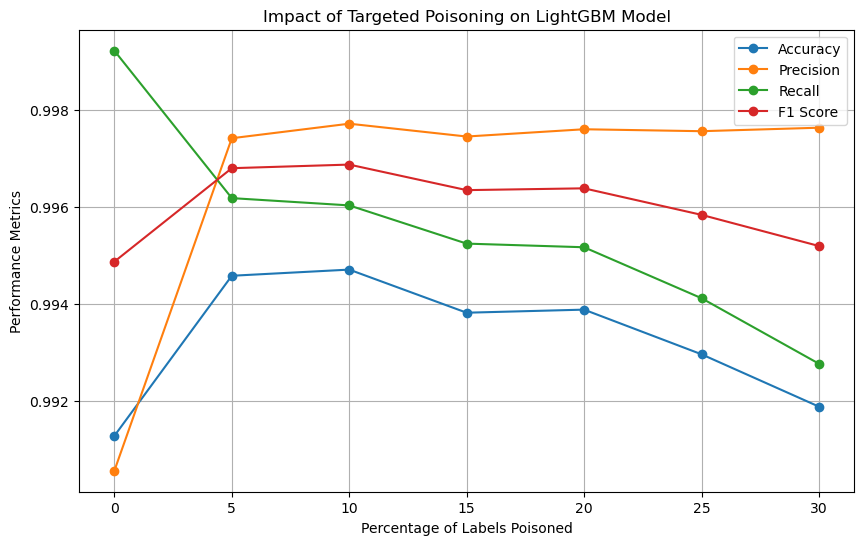


Part B - Poisoning Impact Table:
   Poison %  Accuracy  Precision    Recall  F1 Score
0         0  0.991286   0.990569  0.999213  0.994873
1         5  0.994582   0.997413  0.996180  0.996796
2        10  0.994708   0.997711  0.996030  0.996870
3        15  0.993821   0.997448  0.995243  0.996344
4        20  0.993885   0.997597  0.995169  0.996381
5        25  0.992966   0.997557  0.994120  0.995836
6        30  0.991888   0.997629  0.992772  0.995194


In [18]:
#Visualize Impact
results_df = pd.DataFrame(results, columns=['Poison %', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

plt.figure(figsize=(10, 6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    plt.plot(results_df['Poison %'], results_df[metric], marker='o', label=metric)

plt.title('Impact of Targeted Poisoning on LightGBM Model')
plt.xlabel('Percentage of Labels Poisoned')
plt.ylabel('Performance Metrics')
plt.grid(True)
plt.legend()
plt.show()

print("\nPart B - Poisoning Impact Table:")
print(results_df)  

SECTION C

In [20]:
import hashlib

def compute_batch_hash(X_batch, y_batch):
    data_string = str(X_batch.tolist()) + str(y_batch.tolist())
    return hashlib.sha256(data_string.encode()).hexdigest()

# Simulate blockchain
blockchain = []

In [21]:
# Create block for current training set
block_hash = compute_batch_hash(X_train_scaled, y_train)
blockchain.append(block_hash)


In [22]:
# Verify before training
current_hash = compute_batch_hash(X_train_scaled, y_train)

print("\nPart C - Blockchain Integrity Check:")
if blockchain[-1] == current_hash:
    print("Integrity OK: No label tampering detected.")
else:
    print("Integrity Breach: Labels/Data have been altered!")


Part C - Blockchain Integrity Check:
Integrity OK: No label tampering detected.
